In [2]:
%pip install squidpy

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
  Using cached multiscale_spatial_image-2.0.2-py3-none-any.whl.metadata (25 kB)
  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
  Using cached xarray_dataclasses-1.9.1-py3-none-any.whl.metadata (10 kB)
  Using cached xarray_schema-0.0.3-py3-none-any.whl.metadata (4.3 kB)
  Using cached xarray_spatial-0.4.0-py3-none-any.whl.metadata (16 kB)
  Using cached colorcet-3.1.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached multipledispatch-1.0.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyct-0.5.0-py2.py3-none-any.whl.metadata (7.4 kB)
  Using cached markdown_it_py-3.0.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached mdurl-0.1.2-py3-none-any

In [3]:
import squidpy as sq
import pandas as pd
import sys
import os
import scanpy as sc
import seaborn as sns; sns.set(color_codes=True)
import anndata
adata = anndata.read_h5ad('/data/vasileiosionat2/Xenium/Drake_outputs/ccProcessed.h5ad')

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.r

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
  0%|                                                                                                 | 0/100 [00:00<?, ?permutation/s]/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/numba/parfors/parfor.py:2395: NumbaPerformanceWarning: 
prange or pndindex loop will not be executed in parallel due to there being more than one entry to or exit from the loop (e.g., an assertion).

File "/gpfs/gsfs12/users/vasileiosionat2/github/gingiva-2025/xenium", line 137:
<source missing, REPL/exec in use?>

  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████| 100/100 [1:27:17<00:00, 52.37s/permutation]


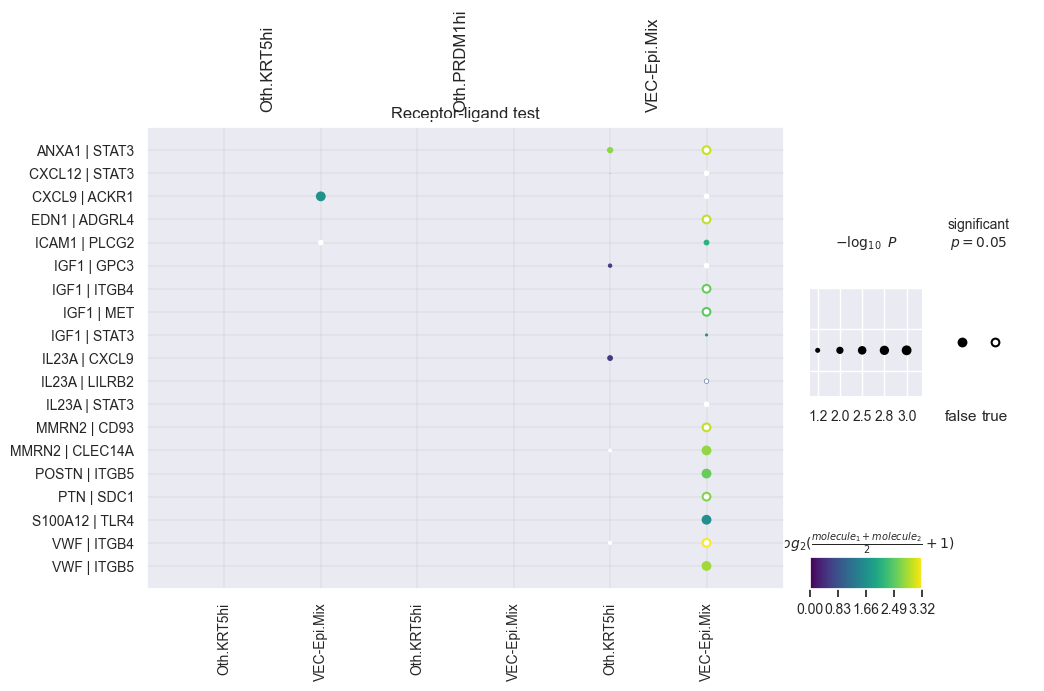

In [6]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd

# --- Load your AnnData object ---
# adata = sc.read_h5ad('your_xenium_data.h5ad')  # if not already loaded

# --- Drop cells without spatial coordinates or cell type ---
adata = adata[
    adata.obs[['x_centroid', 'y_centroid', 'Lvl4']].notnull().all(axis=1)
].copy()

# --- Assign spatial coordinates to obsm ---
adata.obsm['spatial'] = adata.obs[['x_centroid', 'y_centroid']].to_numpy()

# --- Build spatial neighbor graph ---
sq.gr.spatial_neighbors(adata, coord_type='generic')  # Use 'generic' for Xenium

# --- Run ligand–receptor analysis ---
sq.gr.ligrec(
    adata,
    cluster_key='Lvl4',  # change if you use another column like 'lvl1'
    use_raw=False,            # set True if using raw layer
    n_perms=100               # or more (e.g., 1000 for publication-level stats)
)

# --- Plot top ligand–receptor interactions ---
sq.pl.ligrec(
    adata,
    cluster_key='Lvl4',
    n_rows=5,
    alpha=0.05,              # significance threshold
    figsize=(10, 6)
)

In [8]:
adata.obs['niche_knn50k10_merged'].unique().tolist()

['Fibrous CT',
 'Epi-CT',
 'Plasma-Fib CT',
 'Plasma',
 'Spinous',
 'Keratin',
 'Crevicular',
 'Lymphoid']

In [9]:
cluster_names = ["Plasma-Fib CT", "Plasma", "Lymphoid", "Crevicular"]

adata_niches = adata[adata.obs['niche_knn50k10_merged'].isin(cluster_names)].copy()

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
adata_niches.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,Lvl4_kmeans_Mel,Mel_leiden,KNN100_K10,KNN100_K12,spatial_expression_cluster,KNN50_K10,KNN30_K10,KNN10_K10,niche_knn50k10,niche_knn50k10_merged
cell_id,,,,,,,,,,,,,,,,,,,,,
aadnkcmj-1,aadnkcmj-1,831.024902,1709.882690,17,1,0,0,0,18,26.597032,...,NaN,NaN,1,9,1,8,8,3,Plasma-Fib CT,Plasma-Fib CT
aaedmhbh-1,aaedmhbh-1,869.532410,1704.096802,93,0,0,0,0,93,45.156252,...,NaN,NaN,1,9,1,8,8,3,Plasma-Fib CT,Plasma-Fib CT
aaejelio-1,aaejelio-1,839.575256,1691.305054,26,0,0,0,0,26,25.739063,...,NaN,NaN,1,9,1,8,8,1,Plasma-Fib CT,Plasma-Fib CT
aaenabai-1,aaenabai-1,878.547424,1695.683960,114,0,0,0,0,114,59.199846,...,NaN,NaN,1,9,1,8,8,3,Plasma-Fib CT,Plasma-Fib CT
aaepboic-1,aaepboic-1,861.960388,1708.142212,85,0,0,0,0,85,38.292501,...,NaN,NaN,1,9,1,8,8,3,Plasma-Fib CT,Plasma-Fib CT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oimpocjl-1,oimpocjl-1,1548.523193,1297.322021,23,0,0,0,0,23,10.205313,...,NaN,NaN,1,9,1,8,8,3,Plasma-Fib CT,Plasma-Fib CT
oindfjhe-1,oindfjhe-1,1548.593140,1276.395020,27,0,0,0,0,27,16.165938,...,NaN,NaN,1,9,1,8,8,1,Plasma-Fib CT,Plasma-Fib CT
oinegfdb-1,oinegfdb-1,1545.742432,1284.771851,11,0,0,0,0,11,6.050938,...,NaN,NaN,1,9,1,8,8,4,Plasma-Fib CT,Plasma-Fib CT


In [14]:
adata_niches.obs['niche_knn50k10_merged'].value_counts()

niche_knn50k10_merged
Plasma           106411
Plasma-Fib CT    106262
Lymphoid          42564
Crevicular        36871
Name: count, dtype: int64

In [15]:
adata_niches.obs['niche_knn50k10_merged'] = adata_niches.obs['niche_knn50k10_merged'].astype('category')

In [16]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd

# --- Load your AnnData object ---
# adata = sc.read_h5ad('your_xenium_data.h5ad')  # if not already loaded

# --- Drop cells without spatial coordinates or cell type ---
adata_niches = adata_niches[
    adata_niches.obs[['x_centroid', 'y_centroid', 'niche_knn50k10_merged']].notnull().all(axis=1)
].copy()

# --- Assign spatial coordinates to obsm ---
adata_niches.obsm['spatial'] = adata_niches.obs[['x_centroid', 'y_centroid']].to_numpy()

# --- Build spatial neighbor graph ---
sq.gr.spatial_neighbors(adata_niches, coord_type='generic')  # Use 'generic' for Xenium

# --- Run ligand–receptor analysis ---
sq.gr.ligrec(
    adata_niches,
    cluster_key='niche_knn50k10_merged',  # change if you use another column like 'lvl1'
    use_raw=False,            # set True if using raw layer
    n_perms=1000               # or more (e.g., 1000 for publication-level stats)
)

# --- Plot top ligand–receptor interactions ---
sq.pl.ligrec(
    adata_niches,
    cluster_key='niche_knn50k10_merged',
    n_rows=5,
    alpha=0.05,              # significance threshold
    figsize=(10, 6)
)

/gpfs/gsfs12/users/vasileiosionat2/conda/envs/squidpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
100%|█████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [43:47<00:00,  2.63s/permutation]


ValueError: After removing rows with only NaN interactions, none remain.